In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Basic info
print(df.info())

# Summary stats
print(df.describe())

# Check first rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check missing values
df.isnull().sum()

# Check for blank spaces
(df == " ").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [4]:
# Replace blank with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)

# Convert to float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Fill missing values (median recommended)
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_1232/2050809048.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [5]:
df.drop("customerID", axis=1, inplace=True)

In [6]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [7]:
def tenure_group(x):
    if x <= 12:
        return "0-12"
    elif x <= 24:
        return "13-24"
    elif x <= 48:
        return "25-48"
    else:
        return "48+"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

In [8]:
df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)

In [9]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])

In [11]:
df = pd.get_dummies(df, columns=["Contract", "InternetService", "PaymentMethod"], drop_first=True)

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

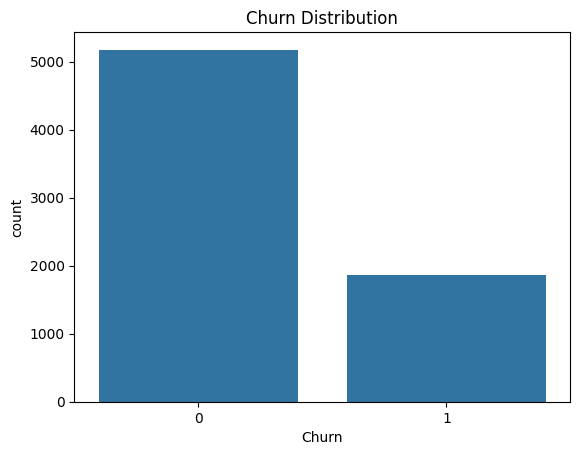

In [13]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

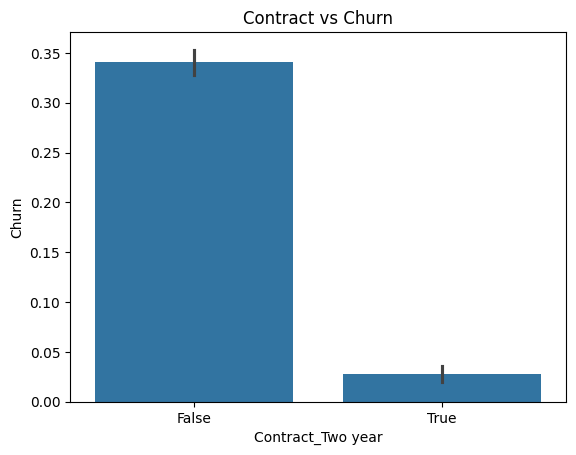

In [14]:
sns.barplot(x="Contract_Two year", y="Churn", data=df)
plt.title("Contract vs Churn")
plt.show()

In [19]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

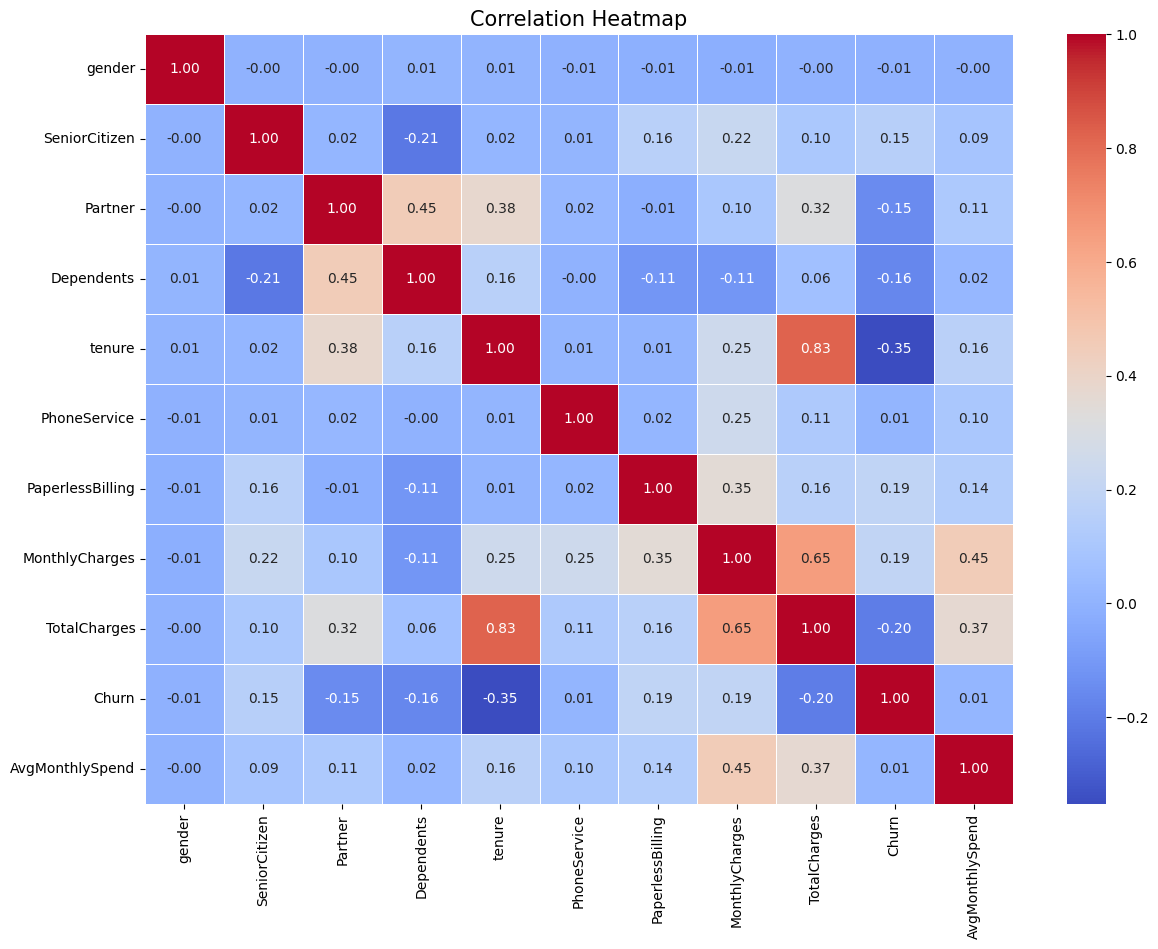

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=True,       # shows values
    fmt=".2f",        # 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=15)
plt.show()

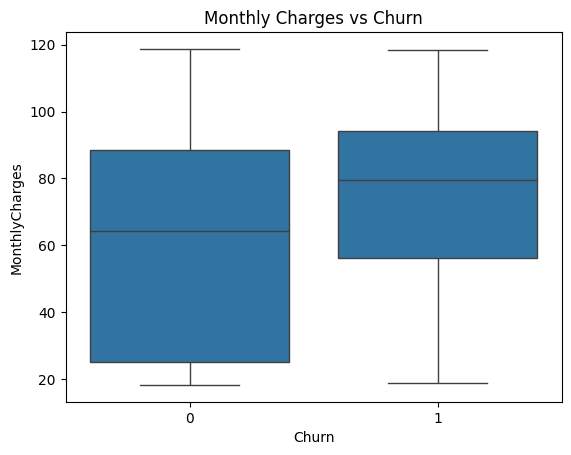

In [20]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [22]:
df.to_csv("cleaned_churn_data.csv", index=False)

Top 5 Insights – Customer Churn Analysis

1. Customers with Short Tenure Are More Likely to Churn

 Customers in the 0–12 months tenure group show the highest churn rate.
 Indicates onboarding experience and early engagement are critical.

2. Higher Monthly Charges Lead to Higher Churn

Customers paying higher monthly fees are more likely to leave.
 Suggests pricing sensitivity or dissatisfaction with value.

3. Long-Term Contracts Significantly Reduce Churn

Customers with 1-year and 2-year contracts have much lower churn compared to month-to-month users.
Contract commitment improves retention.

4. Fiber Optic Internet Users Have Higher Churn

Customers using fiber optic services show higher churn rates than DSL users.
Possible reasons: higher cost, service expectations, or competition.

5. Electronic Check Payment Method Has Highest Churn

Customers paying via electronic check tend to churn more frequently.
Indicates potential friction in payment experience or customer segment behavior.
